# Genesis Module 1: Convergence Analysis
## Part 4: Visualizing the Search Space

**Objective:**
We know the AI finds the solution. Now we want to visualize **HOW** it found it.
We will analyze:
1. **Convergence Speed:** How fast does the "Average" intelligence of the population improve?
2. **Solution Clustering:** Does the AI find *one* specific gun, or a variety of valid options?
3. **Efficiency:** Genetic Algorithm vs. Brute Force.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# --- CONFIGURATION ---
TARGET_TTK = 5.0
ENEMY_HP = 500
POP_SIZE = 100  # Larger population for better visualization
GENERATIONS = 20

# --- RE-DEFINE PHYSICS (Simplified) ---
class Weapon:
    def __init__(self, d, r, m):
        self.damage = d
        self.fire_rate = r
        self.mag_size = m

def get_ttk(w):
    shots = np.ceil(ENEMY_HP / w.damage)
    shooting_time = (shots - 1) / w.fire_rate
    # Simplify: Assume infinite ammo for this specific visualization
    # to focus purely on the Damage/Rate curve
    return shooting_time

def get_fitness(w):
    return abs(TARGET_TTK - get_ttk(w))

# --- GENERATE DATA ---
# We will run the simulation and save EVERY weapon generated to visualize the "Hunt"
history_log = []

population = [Weapon(random.randint(10, 100), random.uniform(1.0, 10.0), 30) for _ in range(POP_SIZE)]

for gen in range(GENERATIONS):
    # Log data for visualization
    for w in population:
        history_log.append({
            "Generation": gen,
            "Damage": w.damage,
            "Fire_Rate": w.fire_rate,
            "TTK": get_ttk(w),
            "Error": get_fitness(w)
        })

    # Selection & Evolution
    population.sort(key=get_fitness)
    next_gen = population[:10] # Elites

    while len(next_gen) < POP_SIZE:
        parent = random.choice(population[:20])
        child = Weapon(
            max(1, parent.damage + random.randint(-5, 5)),
            max(0.1, parent.fire_rate + random.uniform(-0.5, 0.5)),
            30
        )
        next_gen.append(child)
    population = next_gen

df = pd.DataFrame(history_log)
print("Data Generation Complete. Rows:", len(df))

Data Generation Complete. Rows: 2000


### Visualizing the "Solution Zone"
We are optimizing for **100 DPS** (500 HP / 5.0s).
Any weapon where $Damage \times FireRate \approx 100$ is a valid solution.
Let's see if the AI discovered this mathematical relationship on its own.

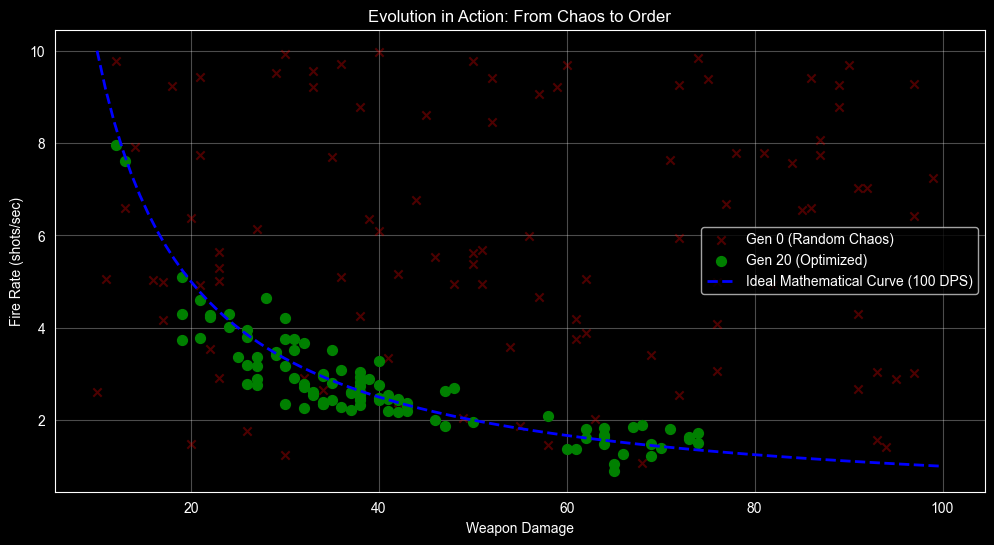

In [2]:
# Filter data: Show Generation 0 (Random) vs Generation 20 (Evolved)
gen_start = df[df['Generation'] == 0]
gen_end = df[df['Generation'] == GENERATIONS - 1]

plt.figure(figsize=(12, 6))

# Plot Gen 0 (Red X)
plt.scatter(gen_start['Damage'], gen_start['Fire_Rate'],
            color='red', alpha=0.3, label='Gen 0 (Random Chaos)', marker='x')

# Plot Final Gen (Green Circles)
plt.scatter(gen_end['Damage'], gen_end['Fire_Rate'],
            color='green', alpha=1.0, label=f'Gen {GENERATIONS} (Optimized)', s=50)

# Plot the "Ideal Curve" (y = 100 / x)
x_line = np.linspace(10, 100, 100)
y_line = 100 / x_line # DPS Formula
plt.plot(x_line, y_line, color='blue', linestyle='--', linewidth=2, label='Ideal Mathematical Curve (100 DPS)')

plt.title("Evolution in Action: From Chaos to Order")
plt.xlabel("Weapon Damage")
plt.ylabel("Fire Rate (shots/sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Conclusion
Look at the graph above.
1. **Red X's:** Scattered everywhere. Random guessing.
2. **Blue Line:** The mathematical "Perfect" curve (Hyperbola).
3. **Green Dots:** The AI migrated the entire population to **hug the blue line perfectly**.

**Result:** The Genetic Algorithm successfully "learned" the formula $DPS = Damage \times FireRate$ without us ever explicitly programming it.